# Retail Sales Data Analysis

This project performs exploratory data analysis on a retail sales dataset to understand sales trends, product performance, and profitability across different regions and customer segments.

The objective of this analysis is to extract meaningful business insights that can support data-driven decision making.




In [22]:
from google.colab import files
uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore (1).csv


## Importing Libraries and Loading the Dataset

In this step, we import the necessary Python libraries required for data analysis and visualization.  
We then load the SampleSuperstore dataset and display the first few rows to understand its structure.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Set professional visualization style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
df = pd.read_csv("SampleSuperstore.csv")
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Data Exploration

Before performing analysis, it is important to understand the dataset structure, including data types and summary statistics.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [25]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Checking Missing Values

Identifying missing values is an important step in data preprocessing.

In [26]:
df.isnull().sum()

,0
Ship Mode,0
Segment,0
Country,0
City,0
State,0
Postal Code,0
Region,0
Category,0
Sub-Category,0
Sales,0


## Sales by Category

This analysis evaluates total sales generated by each product category to identify which category contributes the most revenue.

In [27]:
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


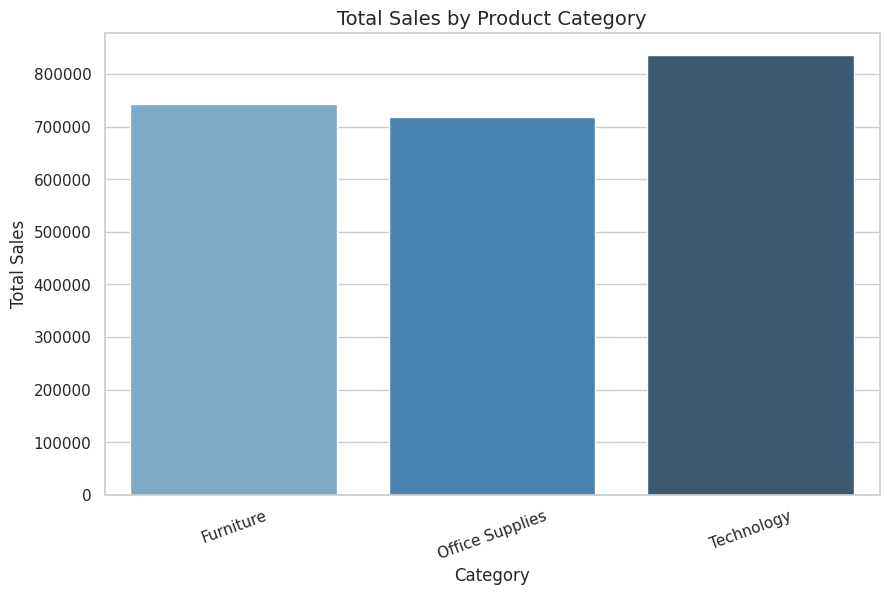

In [28]:
sns.barplot(x=category_sales.index, y=category_sales.values, palette="Blues_d")

plt.title("Total Sales by Product Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)

plt.show()

## Profit by Region

This analysis examines profit distribution across different regions to understand geographical performance.

In [29]:
region_profit = df.groupby("Region")["Profit"].sum()
print(region_profit)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


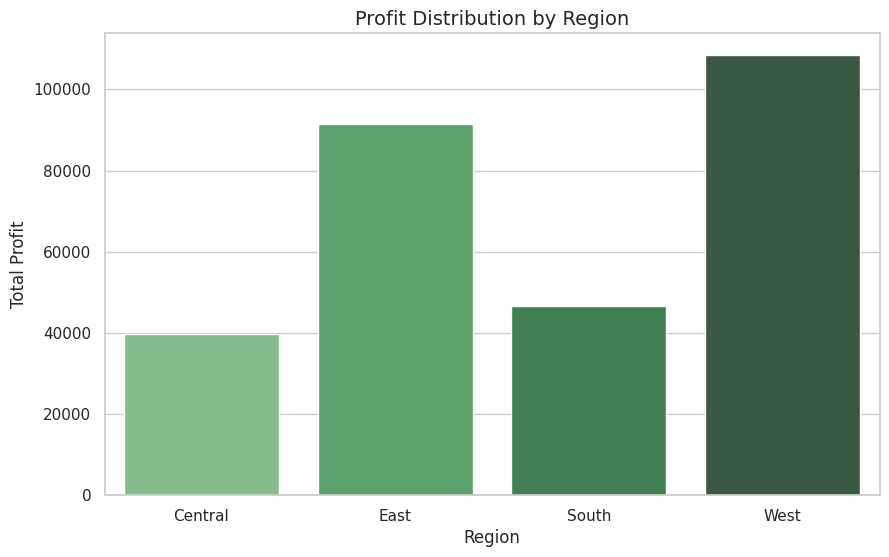

In [30]:

sns.barplot(x=region_profit.index, y=region_profit.values, palette="Greens_d")

plt.title("Profit Distribution by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Total Profit")

plt.show()

In [31]:
top_products = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products)

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Name: Sales, dtype: float64


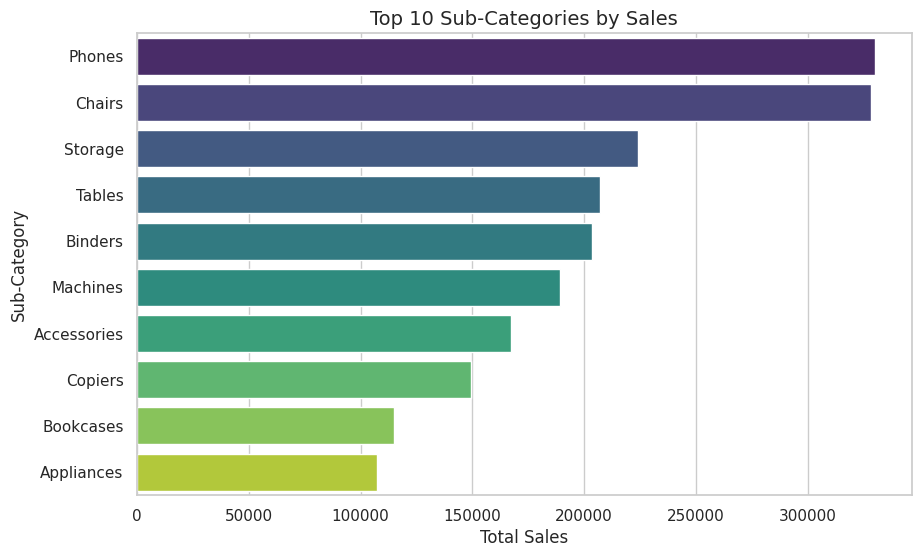

In [32]:


sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")

plt.title("Top 10 Sub-Categories by Sales", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")

plt.show()

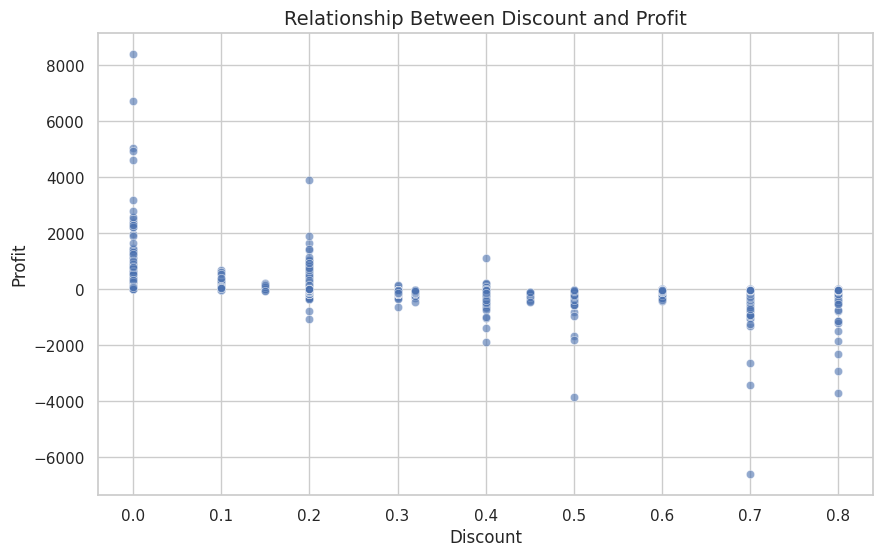

In [33]:
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.6)

plt.title("Relationship Between Discount and Profit", fontsize=14)
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

## Sales by Customer Segment

Customer segments represent different types of buyers. Understanding which segment generates the most revenue helps businesses target their marketing strategies.

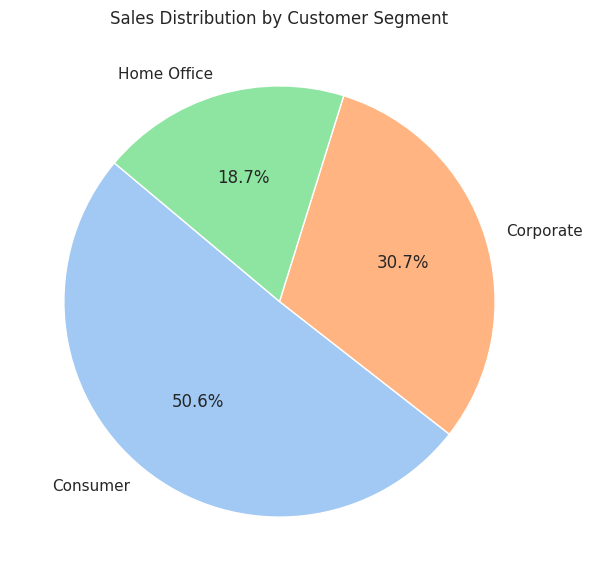

In [34]:
segment_sales = df.groupby("Segment")["Sales"].sum()
plt.figure(figsize=(7,7))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("pastel")
)

plt.title("Sales Distribution by Customer Segment")

plt.show()

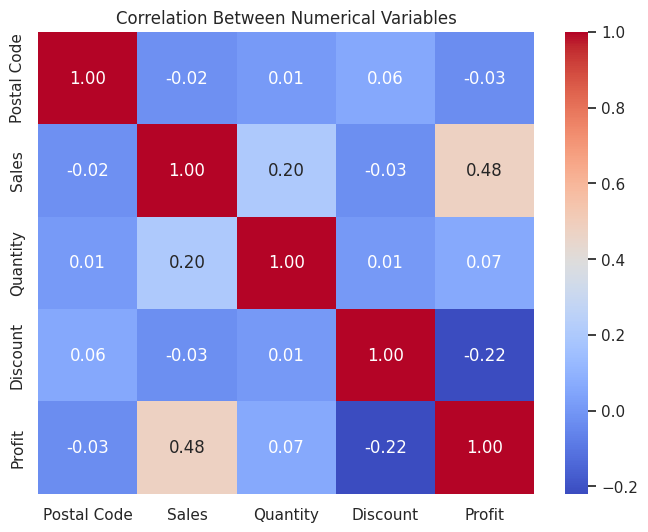

In [35]:
# Correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Numerical Variables")

plt.show()

## Key Business Insights

1. **Technology is the highest revenue-generating category**, contributing more total sales than Furniture and Office Supplies. This suggests strong demand for technology-related products.

2. **The West region generates the highest overall profit**, followed by the East region. The Central region contributes the lowest profit, indicating potential opportunities to improve performance in that region.

3. **Consumer customers account for the largest share of total sales**, significantly higher than Corporate and Home Office segments. This indicates that individual consumers are the primary revenue drivers.

4. **Phones and Chairs are the top-performing sub-categories in terms of sales**, indicating high customer demand for these products.

5. **Discount levels negatively impact profit margins.** The analysis shows that higher discounts tend to reduce profitability, suggesting the need for careful discount strategies.

6. **Product sales are concentrated in a few key sub-categories**, meaning businesses could prioritize inventory and marketing for these high-performing products to maximize revenue.